In [77]:
import pandas as pd
import numpy as np
# import mlextend
# from mlextend.plotting import plot_decision_regions


In [5]:
df=pd.DataFrame()
df['X1']=[1,2,3,4,5,6,6,7,9,9]
df['X2']=[5,3,6,8,1,9,5,8,9,2]
df['label']=[1,1,0,1,0,1,0,1,0,0]
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

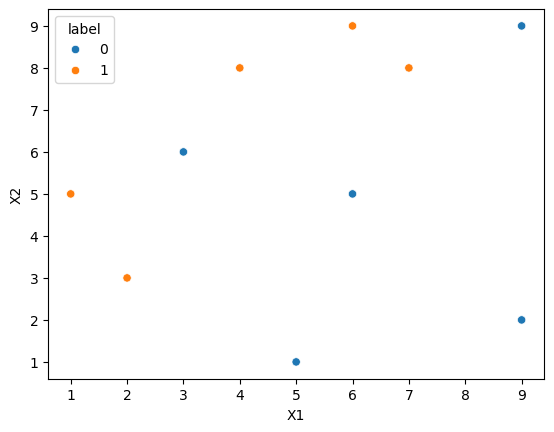

In [6]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [7]:
df['weights']=1/df.shape[0]

In [8]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [12]:
from sklearn.tree import DecisionTreeClassifier
dft1=DecisionTreeClassifier(max_depth=1)
# in ada boost therewillbe decision stumps that will have max depth has 1
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [13]:
dft1.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

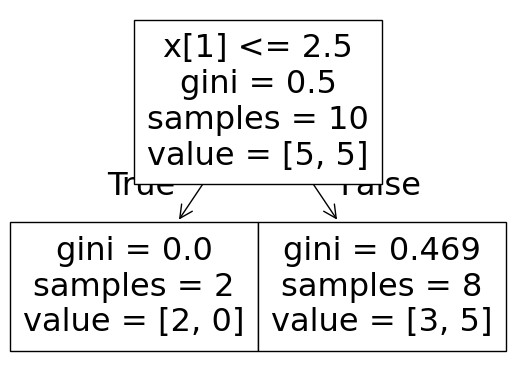

In [14]:
from sklearn.tree import plot_tree
plot_tree(dft1)

In [18]:
# decision treee is divided based on the 2 column which means X[1]
df['y_pred']=dft1.predict(X)

In [19]:
df


,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [20]:
# in row 2,6,8 row was predicted wrong
# so totsl_error is 0.1+0.1+0.1 (adding the weights of wrongly predicted row)
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error))
    

In [21]:
alpha1=calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [26]:
# next step
#Increase weights for misclassified samples.
# Decrease weights for correctly classified samples.
def update_row_weights(row,alpha=0.423):
    if(row['label']==row['y_pred']):
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)
        

In [27]:
df['update_weights']=df.apply(update_row_weights,axis=1)
df

,X1,X2,label,weights,y_pred,update_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [29]:
df['update_weights'].sum()
# it should be equal to 1 until then u should normalize

np.float64(0.9165153319682015)

In [30]:
df['normalized_weights']=df['update_weights']/df['update_weights'].sum()

In [31]:
df

,X1,X2,label,weights,y_pred,update_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [32]:
df['normalized_weights'].sum()

np.float64(1.0)

In [33]:
 #  to create range
df['cumsum_upper']=np.cumsum(df['normalized_weights'])


In [34]:
df['cumsum_lower']=df['cumsum_upper']-df['normalized_weights']

In [35]:
df

,X1,X2,label,weights,y_pred,update_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [41]:
#  create new dataset by choosing random numbers and checking 
# in which range that random number lie where lower range is cumsum_lower
#  and upper boundary is cumsum_upper
def create_new_dataset(df):
    indices=[]
    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper']>a and a>row['cumsum_lower']:
                indices.append(index)
    return indices

In [42]:
index_values=create_new_dataset(df)
index_values

[3, 7, 2, 3, 2, 5, 8, 6, 2, 4]

In [43]:
second_df=df.iloc[index_values,[0,1,2,3]]

In [44]:
second_df

,X1,X2,label,weights
3,4,8,1,0.1
7,7,8,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
2,3,6,0,0.1
5,6,9,1,0.1
8,9,9,0,0.1
6,6,5,0,0.1
2,3,6,0,0.1
4,5,1,0,0.1


[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.625, 0.5, '  False')]

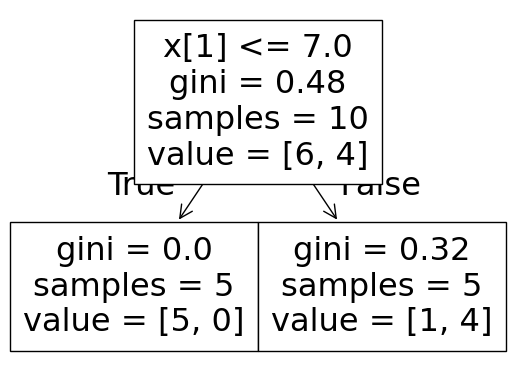

In [47]:
dft2=DecisionTreeClassifier(max_depth=1)
X=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values
dft2.fit(X,y)
plot_tree(dft2)

In [48]:
second_df['y_pred']=dft2.predict(X)

In [49]:
second_df

,X1,X2,label,weights,y_pred
3,4,8,1,0.1,1
7,7,8,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,1
2,3,6,0,0.1,0
5,6,9,1,0.1,1
8,9,9,0,0.1,1
6,6,5,0,0.1,0
2,3,6,0,0.1,0
4,5,1,0,0.1,0


In [50]:
# only row 8 is wrongly predicted
alpha2=calculate_model_weight(0.1)
alpha2

np.float64(1.0986122886681098)

In [51]:
# next step
#Increase weights for misclassified samples.
# Decrease weights for correctly classified samples.
def update_row_weights(row,alpha=1.09):
    if(row['label']==row['y_pred']):
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)
        

In [52]:
second_df['updated_weights']=df.apply(update_row_weights,axis=1)

In [53]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
3,4,8,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
2,3,6,0,0.1,0,0.297427
3,4,8,1,0.1,1,0.033622
2,3,6,0,0.1,0,0.297427
5,6,9,1,0.1,1,0.033622
8,9,9,0,0.1,1,0.297427
6,6,5,0,0.1,0,0.297427
2,3,6,0,0.1,0,0.297427
4,5,1,0,0.1,0,0.033622


In [54]:
second_df['normailzed_weights']=second_df['updated_weights']/second_df['updated_weights'].sum()

In [55]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normailzed_weights
3,4,8,1,0.1,1,0.033622,0.020312
7,7,8,1,0.1,1,0.033622,0.020312
2,3,6,0,0.1,0,0.297427,0.179688
3,4,8,1,0.1,1,0.033622,0.020312
2,3,6,0,0.1,0,0.297427,0.179688
5,6,9,1,0.1,1,0.033622,0.020312
8,9,9,0,0.1,1,0.297427,0.179688
6,6,5,0,0.1,0,0.297427,0.179688
2,3,6,0,0.1,0,0.297427,0.179688
4,5,1,0,0.1,0,0.033622,0.020312


In [56]:
second_df['normailzed_weights'].sum()

np.float64(0.9999999999999999)

In [60]:
second_df['cumsum_upper']=np.cumsum(second_df['normailzed_weights'])


In [61]:
second_df['cumsum_lower']=second_df['cumsum_upper']-second_df['normailzed_weights']

In [62]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normailzed_weights,cumsum_upper,cumsum_lower
3,4,8,1,0.1,1,0.033622,0.020312,0.020312,0.000000
7,7,8,1,0.1,1,0.033622,0.020312,0.040624,0.020312
2,3,6,0,0.1,0,0.297427,0.179688,0.220312,0.040624
3,4,8,1,0.1,1,0.033622,0.020312,0.240624,0.220312
2,3,6,0,0.1,0,0.297427,0.179688,0.420312,0.240624
5,6,9,1,0.1,1,0.033622,0.020312,0.440624,0.420312
8,9,9,0,0.1,1,0.297427,0.179688,0.620312,0.440624
6,6,5,0,0.1,0,0.297427,0.179688,0.800000,0.620312
2,3,6,0,0.1,0,0.297427,0.179688,0.979688,0.800000
4,5,1,0,0.1,0,0.033622,0.020312,1.000000,0.979688


In [63]:
def create_new_dataset(df):
    indices=[]
    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper']>a and a>row['cumsum_lower']:
                indices.append(index)
    return indices
    

In [64]:
index_values=create_new_dataset(df)
index_values

[1, 6, 4, 1, 8, 6, 1, 8, 3, 2]

In [65]:
third_df=second_df.iloc[index_values,[0,1,2,3]]

In [66]:
third_df

,X1,X2,label,weights
7,7,8,1,0.1
8,9,9,0,0.1
2,3,6,0,0.1
7,7,8,1,0.1
2,3,6,0,0.1
8,9,9,0,0.1
7,7,8,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
2,3,6,0,0.1


In [72]:
dft3=DecisionTreeClassifier(max_depth=1)
X=third_df.iloc[:,0:2].values
y=third_df.iloc[:,2].values

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.625, 0.5, '  False')]

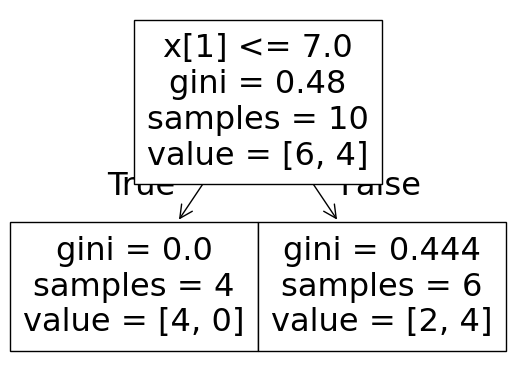

In [74]:
dft3.fit(X,y)
plot_tree(dft3)

In [75]:
third_df['y_pred']=dft3.predict(X)

In [76]:
third_df


,X1,X2,label,weights,y_pred
7,7,8,1,0.1,1
8,9,9,0,0.1,1
2,3,6,0,0.1,0
7,7,8,1,0.1,1
2,3,6,0,0.1,0
8,9,9,0,0.1,1
7,7,8,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,1
2,3,6,0,0.1,0


In [78]:
# continue the remainig steps it our wish to create as many decision stumps


In [78]:
# OR

In [79]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

X = df[['X1','X2']]
y = df['label']

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(criterion='gini',max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X, y)

y_pred = ada.predict(X)

In [81]:
y,y_pred

(0    1
 1    1
 2    0
 3    1
 4    0
 5    1
 6    0
 7    1
 8    0
 9    0
 Name: label, dtype: int64,
 array([1, 1, 0, 1, 0, 1, 0, 1, 0, 0]))

In [82]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y, y_pred))

1.0


In [83]:
len(ada.estimators_)

50

In [84]:
ada.estimators_[0]

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1608637542
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [85]:
ada.estimators_[1]

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1273642419
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [86]:
ada.estimator_weights_
# Higher weight ⇒ better stump.

array([0.84729786, 1.29928298, 1.40534256, 1.65542303, 1.48022618,
       1.49776823, 1.46460696, 1.46101791, 1.45261136, 1.44981776,
       1.4472013 , 1.44593133, 1.44501733, 1.44450291, 1.44416618,
       1.44396542, 1.44383861, 1.4437613 , 1.44371313, 1.44368351,
       1.44366514, 1.44365382, 1.44364681, 1.44364248, 1.4436398 ,
       1.44363815, 1.44363713, 1.4436365 , 1.44363611, 1.44363587,
       1.44363572, 1.44363562, 1.44363557, 1.44363553, 1.44363551,
       1.4436355 , 1.44363549, 1.44363548, 1.44363548, 1.44363548,
       1.44363548, 1.44363548, 1.44363548, 1.44363548, 1.44363548,
       1.44363548, 1.44363548, 1.44363548, 1.44363548, 1.44363548])

In [87]:
ada.estimator_errors_

array([0.3       , 0.21428571, 0.1969697 , 0.16037736, 0.18539326,
       0.18275862, 0.18776371, 0.18831169, 0.1896    , 0.19002962,
       0.19043266, 0.19062853, 0.19076959, 0.19084902, 0.19090102,
       0.19093203, 0.19095162, 0.19096357, 0.19097101, 0.19097558,
       0.19097842, 0.19098017, 0.19098125, 0.19098192, 0.19098234,
       0.19098259, 0.19098275, 0.19098285, 0.19098291, 0.19098295,
       0.19098297, 0.19098298, 0.19098299, 0.190983  , 0.190983  ,
       0.190983  , 0.190983  , 0.190983  , 0.190983  , 0.19098301,
       0.19098301, 0.19098301, 0.19098301, 0.19098301, 0.19098301,
       0.19098301, 0.19098301, 0.19098301, 0.19098301, 0.19098301])

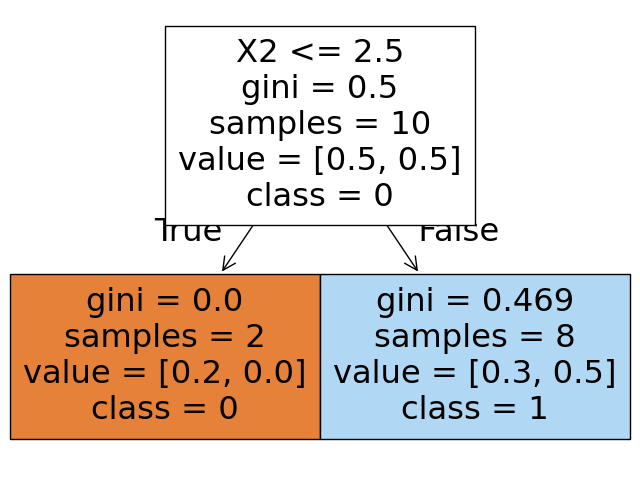

In [88]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

tree.plot_tree(
    ada.estimators_[0],
    filled=True,
    feature_names=X.columns,
    class_names=['0','1']
)

plt.show()
#  this isfirst decision tree stump